# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mig
import tensorflow as df
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam


In [ ]:
# Define zip file paths
train_zip_path = '/MLPR Images-20250426T131308Z-001 (1).zip'


# Define extraction directories
extracted_train_dir = ''


In [ ]:
# Extract the zip files
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_train_dir)



In [ ]:

# Data augmentation & preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_generator = image_dataset_from_directory(
    'MLPR Images',   # All images in one big folder
    image_size=(224, 224),
    labels='inferred',
    label_mode='categorical',        # Resize images
    batch_size=32,
    validation_split=0.3,         # 70% for training
    subset="training",            # Load the training part
    seed=123                      # Fix randomness
)

test_generator = image_dataset_from_directory(
    'MLPR Images',
    image_size=(224, 224),
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    validation_split=0.3,         # 30% for testing
    subset="validation",          # Load the testing part
    seed=123
)


Found 1938 files belonging to 6 classes.
Using 1357 files for training.
Found 1938 files belonging to 6 classes.
Using 581 files for validation.


In [ ]:
# CNN Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout


model_cnn = Sequential()
model_cnn.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(GlobalAveragePooling2D())
model_cnn.add(Dense(units=128, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(units=6, activation='softmax'))

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(train_generator, epochs=10, validation_data=test_generator)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.2148 - loss: 8.0314 - val_accuracy: 0.3012 - val_loss: 1.3758
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.3922 - loss: 1.3827 - val_accuracy: 0.6299 - val_loss: 1.0636
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.5398 - loss: 1.1529 - val_accuracy: 0.8296 - val_loss: 0.7068
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.6826 - loss: 0.8824 - val_accuracy: 0.7143 - val_loss: 0.6824
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.7379 - loss: 0.7266 - val_accuracy: 0.8227 - val_loss: 0.5675
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.7643 - loss: 0.6308 - val_accuracy: 0.8468 - val_loss: 0.5031
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.8251 - loss: 0.4945 - val_accuracy: 0.8812 - val_loss: 0.3745
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.8180 - loss: 0.5558 - val_accuracy: 0.8554 - v

In [ ]:
 # Display CNN model accuracy and summary
cnn_accuracy = model_cnn.evaluate(test_generator)[1] * 100
print(f"CNN Model Accuracy: {cnn_accuracy:.2f}%")
model_cnn.summary()

19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9265 - loss: 0.2953
CNN Model Accuracy: 91.22%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,460 (333.83 KB)

 Trainable params: 28,486 (111.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,974 (222.56 KB)

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Data Augmentation
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.05)
])

# Base Model: MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # Freeze the base model initially


# Build Transfer Learning Model
model_transfer = Sequential([
    data_augmentation,                       # Add data augmentation first
    Rescaling(1./127.5, offset=-1),           # MobileNetV2 expects inputs between -1 and 1
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')            # 6 classes output
])

# Compile Model
model_transfer.compile(
    optimizer=Adam(learning_rate=1e-4),        # Small learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.2)

# Train New Top Layers (initial training)
history = model_transfer.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# Fine-tune some layers
# Unfreeze the top 30 layers of base_model for fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile after changing trainable layers
model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5),         # Even smaller lr for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training (fine-tuning)
model_transfer.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.2692 - loss: 2.2467 - val_accuracy: 0.3941 - val_loss: 1.1859 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.5100 - loss: 1.2679 - val_accuracy: 0.5852 - val_loss: 0.9017 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.6532 - loss: 0.8925 - val_accuracy: 0.7797 - val_loss: 0.6458 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.7068 - loss: 0.8045 - val_accuracy: 0.8761 - val_loss: 0.4945 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.7726 - loss: 0.6737 - val_accuracy: 0.8933 - val_loss: 0.4220 - learning_rate: 1.0000e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.8048 - loss: 0.5876 - val_accuracy: 0.9346 - val_loss: 0.3332 - learning_rate: 1.0000e-04
Epoch 7/10
43/43 ━━━━

In [ ]:
# Display Transfer model accuracy and summary
tran_accuracy = model_transfer.evaluate(test_generator)[1] * 100
print(f"Transfer Model Accuracy: {tran_accuracy:.2f}%")

model_transfer.summary()

19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9530 - loss: 0.1650
Transfer Model Accuracy: 95.35%


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,805,012 (22.14 MB)

 Trainable params: 1,691,142 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,382,286 (12.90 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


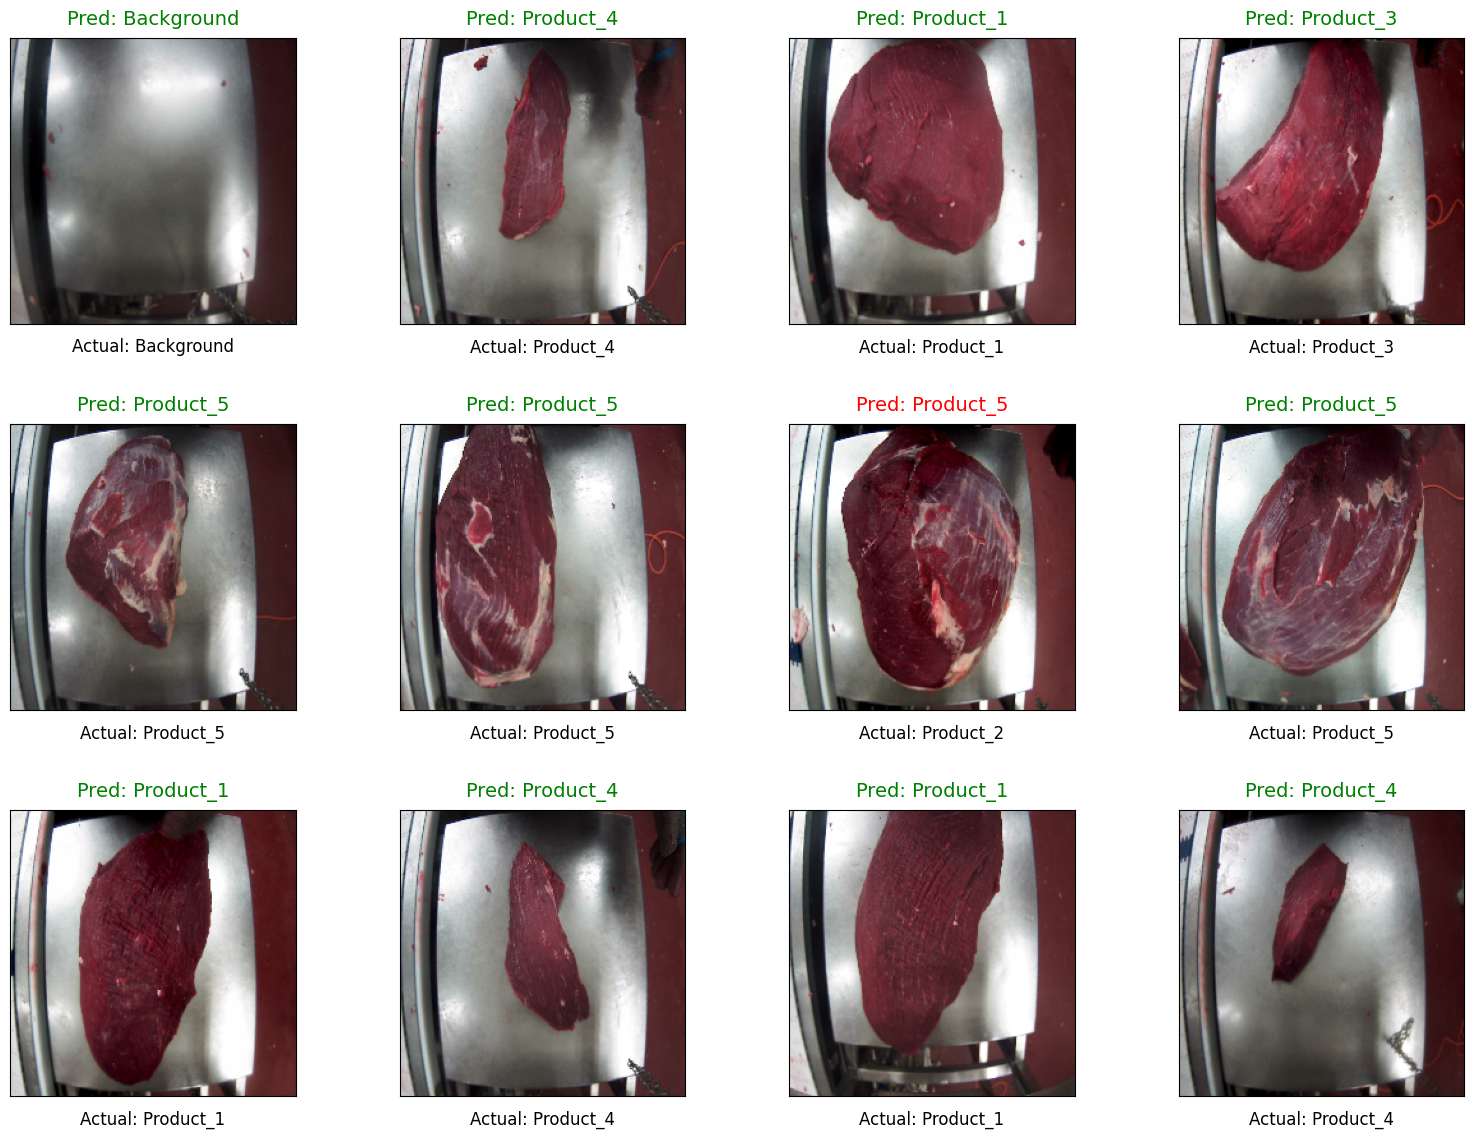

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to visualize model predictions
def visualize_predictions(model, dataset, class_names):
    # Take a batch of images and labels
    for test_images, true_labels in dataset.take(1):   # Take only one batch
        # Make predictions
        predictions = model.predict(test_images)

        # Decode predicted labels
        predicted_labels = np.argmax(predictions, axis=1)
        # Decode true labels
        true_labels = np.argmax(true_labels.numpy(), axis=1)

        plt.figure(figsize=(16, 12))   # Bigger figure size
        for i in range(min(12, len(true_labels))):
            plt.subplot(3, 4, i + 1)
            plt.imshow(test_images[i].numpy().astype("uint8"))

            pred_class = class_names[predicted_labels[i]]
            true_class = class_names[true_labels[i]]

            # Make title color green if correct, red if wrong
            color = 'green' if predicted_labels[i] == true_labels[i] else 'red'

            plt.title(f"Pred: {pred_class}", fontsize=14, color=color, pad=10)
            plt.xlabel(f"Actual: {true_class}", fontsize=12, labelpad=10)
            plt.xticks([])
            plt.yticks([])

        plt.tight_layout(pad=3.0)
        plt.show()

class_names = ['Background','Product_1', 'Product_2', 'Product_3', 'Product_4', 'Product_5']

visualize_predictions(model_transfer, test_generator, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step


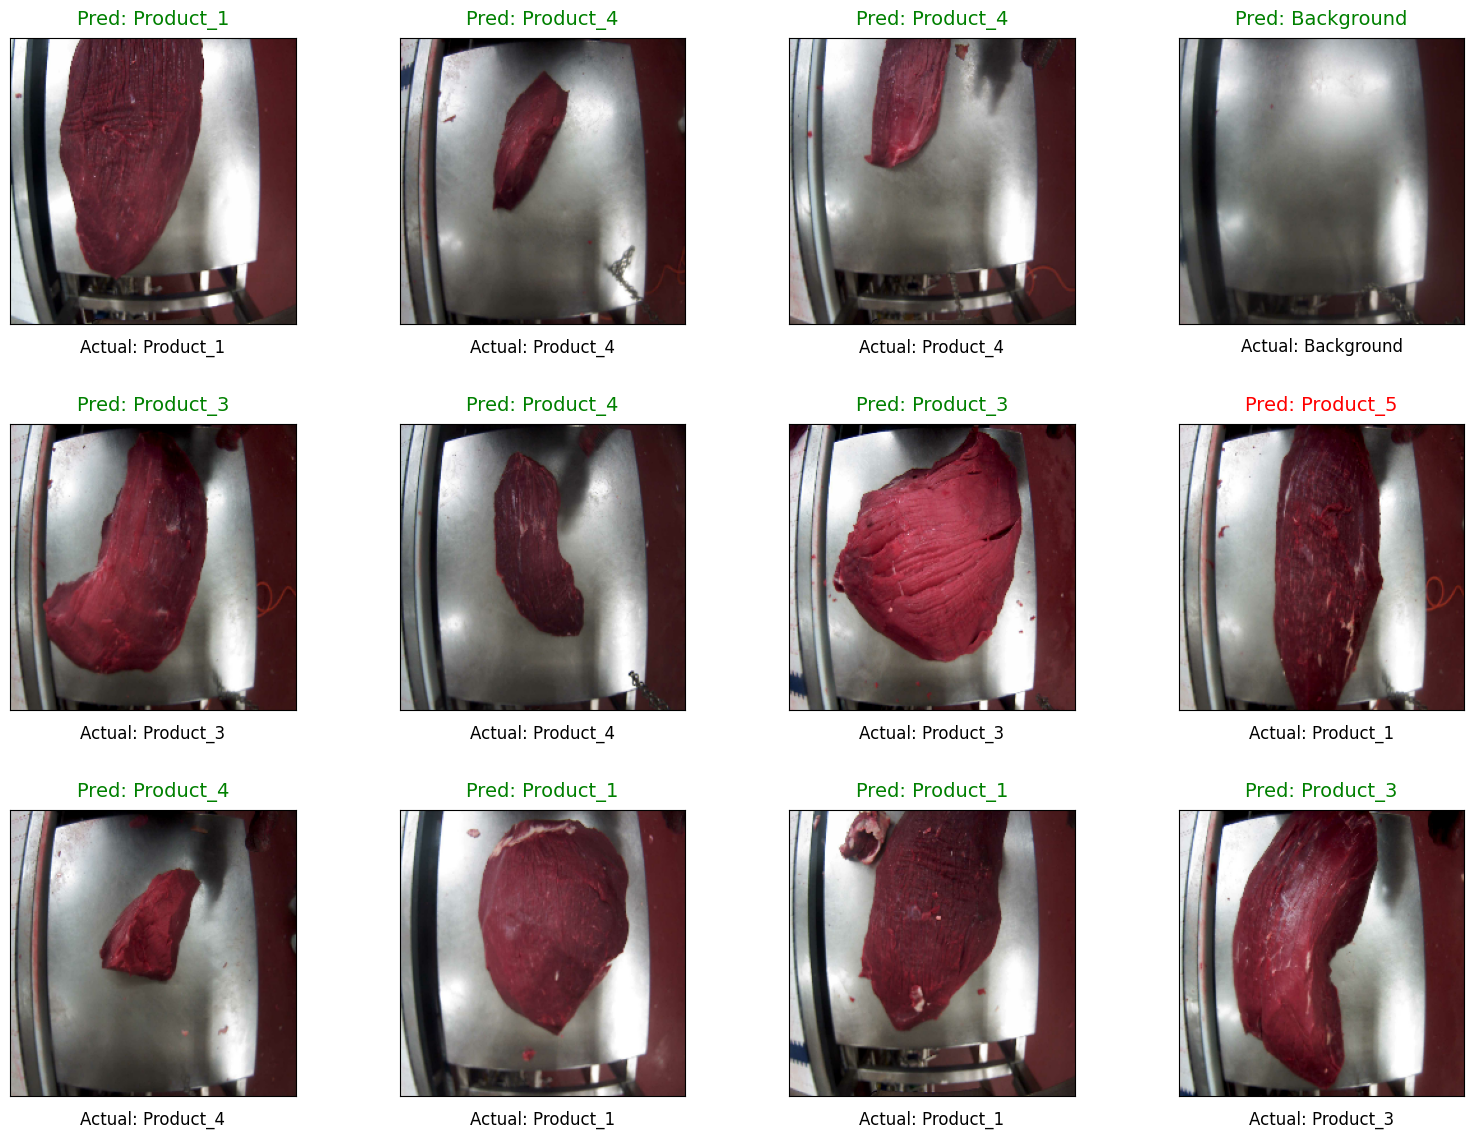

In [ ]:
visualize_predictions(model_cnn, test_generator, class_names)